# **Project Name**    - **YES Bank OHLC Data Analysis and Closing Price Prediction**



##### **Project Type**    - Regression Model
##### **Contribution**    - Individual
##### **Name - Soumojit Ghosh**

# **Project Summary -**

This project focuses on the analysis and prediction of Yes Bank stock closing prices using historical monthly stock data. The dataset contains Date, Open, High, Low, and Close price columns. The target variable for prediction is the Close price, while Open, High, Low, Year, and Month are used as input features.

First, the dataset was loaded and checked for basic information such as shape, data types, missing values, duplicate values, and statistical summary. The dataset did not contain missing or duplicate values, so no major cleaning was required. The Date column was converted into useful numerical features such as Year and Month because stock prices depend strongly on time trends.

Exploratory Data Analysis was performed using different charts such as line plots, bar charts, boxplots, correlation heatmap, and pair plot. These charts helped identify stock price movement, volatility, outliers, and relationships between variables. The analysis showed that Open, High, Low, and Close prices are highly correlated with each other. The stock showed strong growth until 2018, followed by a sharp decline, indicating high risk and volatility during that period.

Outliers were detected in the price columns, but they were not removed because they represent real market behavior. Instead, log transformation was used to reduce their effect. The data was then split into training and testing sets, and scaling was applied to the input features.

Three regression models were built: Linear Regression, Ridge Regression, and Random Forest Regressor. The models were evaluated using MAE, MSE, RMSE, and R2 Score. Linear Regression was selected as the final model because it achieved a very high R2 Score and low error values while remaining simple and easy to interpret.

# **GitHub Link -**

https://github.com/soumojit45/YES_bank_OHLC_Data__Analysis

# **Problem Statement**


**The objective of this project is to analyze Yes Bank’s historical stock price data and build a machine learning model to predict the closing price of the stock. The dataset contains monthly stock price information such as Open, High, Low, and Close prices. The main goal is to understand stock price trends, volatility, and relationships between variables, and then use these insights to create a regression model for closing price prediction.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('data_YesBank_StockPrices.csv')

### Dataset First View

In [3]:
# Dataset First Look
df

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41
...,...,...,...,...,...
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print("Column count : ",len(df.columns))
print("Row count : ",len(df))

Column count :  5
Row count :  185


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

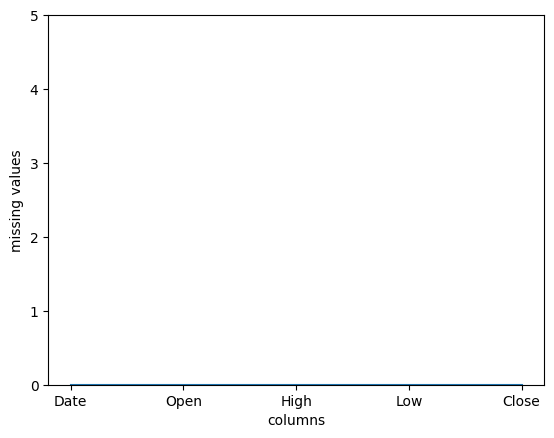

In [8]:
# Visualizing the missing values
plt.plot(df.isnull().sum())
plt.ylabel("missing values")
plt.xlabel("columns")
plt.ylim(0,5)
plt.show()

### **What did you know about your dataset?**

- ***There is no duplicate row***
- ***There is no missing value or NaN value***
- ***There is 185 entries means 185 row***
- ***There is 5 columns***

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [10]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

- Date: Represents the month and year of the stock price record.

- Open: The price at which Yes Bank stock opened during that month.

- High: The highest price reached by Yes Bank stock during that month.

- Low: The lowest price reached by Yes Bank stock during that month.

- Close: The final closing price of Yes Bank stock during that month. This is also the target variable for prediction.

### Check Unique Values for each variable.

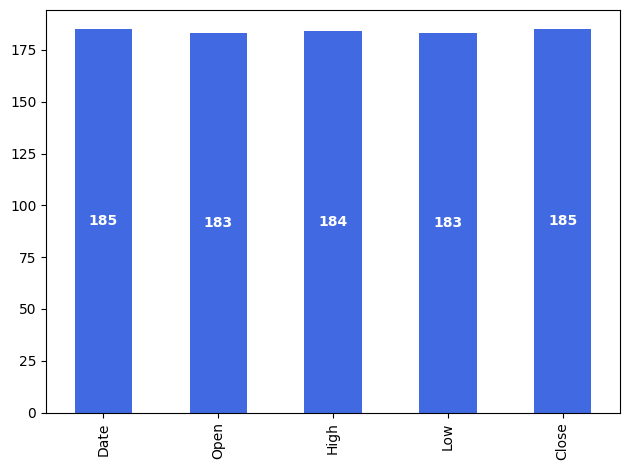

In [11]:
# Check Unique Values for each variable.

ax = df.nunique().plot(kind='bar', color='royalblue')

for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
df_copy_1 = df.copy()
df_copy_1['Price_Range'] = df_copy_1['High']-df_copy_1['Low']

In [13]:
df_copy_1['Return'] = df['Close'].pct_change() * 100
# df_copy_1 

In [14]:
df_model = df.copy()
df_model['Date'] = pd.to_datetime(df_model['Date'], format='%b-%y')

df_model['Year'] = df_model['Date'].dt.year
df_model['Month'] = df_model['Date'].dt.month

### What all manipulations have you done and insights you found?

As there is no missing values or NaN value so i have not to manipulate the data 

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

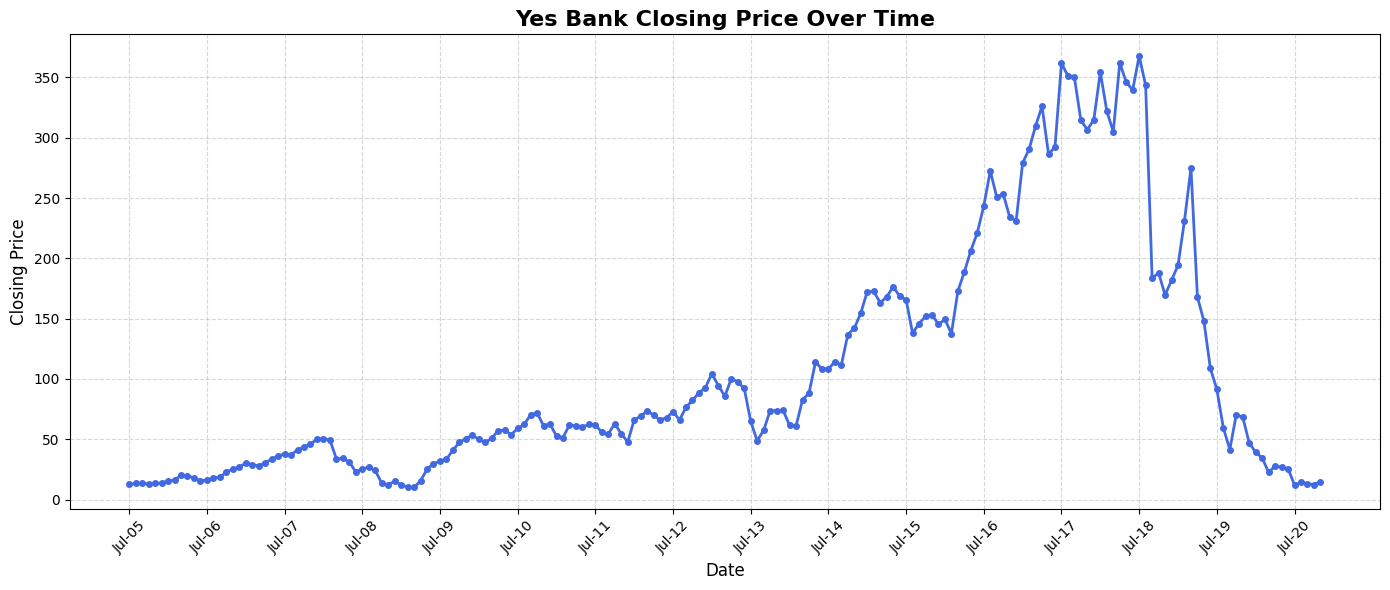

In [15]:
# Chart - 1 visualization code
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], color='royalblue', linewidth=2, marker='o', markersize=4)

plt.title('Yes Bank Closing Price Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price', fontsize=12)

plt.xticks(df['Date'][::12], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I use the line plot of the dates and the closing prices as from this visualization we can see the trend of the closing prices over time 

##### 2. What is/are the insight(s) found from the chart?

- there is a positive growth in the closing prices from the July,2005 to Dec,2007
- the closing price is very low for the time between July,2008 and July,2009
- the growth is good of closing price between July,2013 and July,2015
- from 2016 there is a major jump in the stock price
- from July,2018 to July,2019 the share prices saw a major negative breakdown

##### **3. Will the gained insights help creating a positive business impact?**
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the gained insights can help create a positive business impact because the closing price trend helps investors and analysts understand the overall performance of Yes Bank stock over time. It shows the periods of growth, stability, and decline, which can support better investment decisions.

Yes, there are insights that show negative growth. The closing price dropped sharply from July 2018 to July 2019, which indicates poor stock performance, high risk, and possible loss of investor confidence during that period.

#### Chart - 2

In [16]:
df.iloc[df['High'].argmax()]

Date     Aug-18
Open     369.95
High      404.0
Low       338.0
Close     343.4
Name: 157, dtype: object

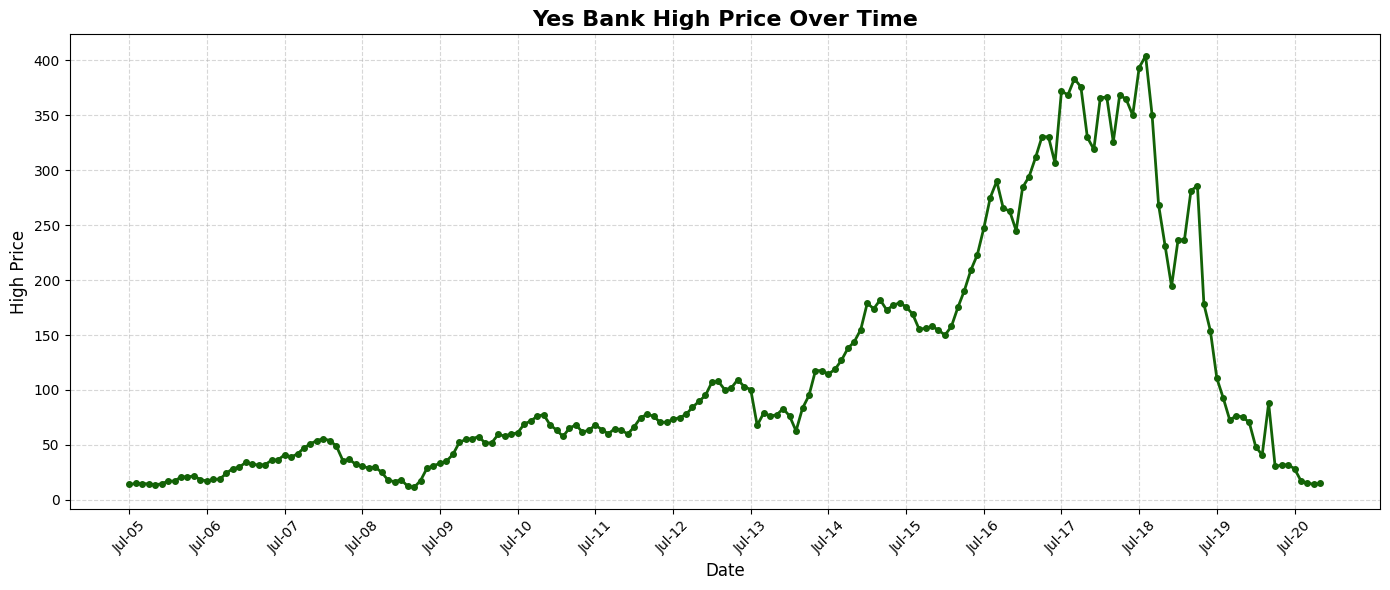

In [17]:
# Chart - 2 visualization code
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['High'], color='#136207', linewidth=2, marker='o', markersize=4)

plt.title('Yes Bank High Price Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('High Price', fontsize=12)

plt.xticks(df['Date'][::12], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I use the line plot of the dates and the high prices as from this visualization we can see the trend of the high prices over time 

##### 2. What is/are the insight(s) found from the chart?

- From July 2014 to August 2017 the high prices are over 150 
- The High price hits the peak of 404 at August 2018 
- After August 2018 there is a major negative growth in high prices 

##### 3. Will the gained insights help creating a positive business impact?

Yes, the gained insights can help create a positive business impact because the high price trend shows the maximum price level Yes Bank stock reached during each period. This helps investors understand the stock’s growth potential and identify strong performing periods.

Yes, there is negative growth after August 2018. The high price reached its peak of 404 in August 2018, but after that it declined sharply, which indicates high market risk, weak investor confidence, and poor stock performance.

Answer Here

#### Chart - 3

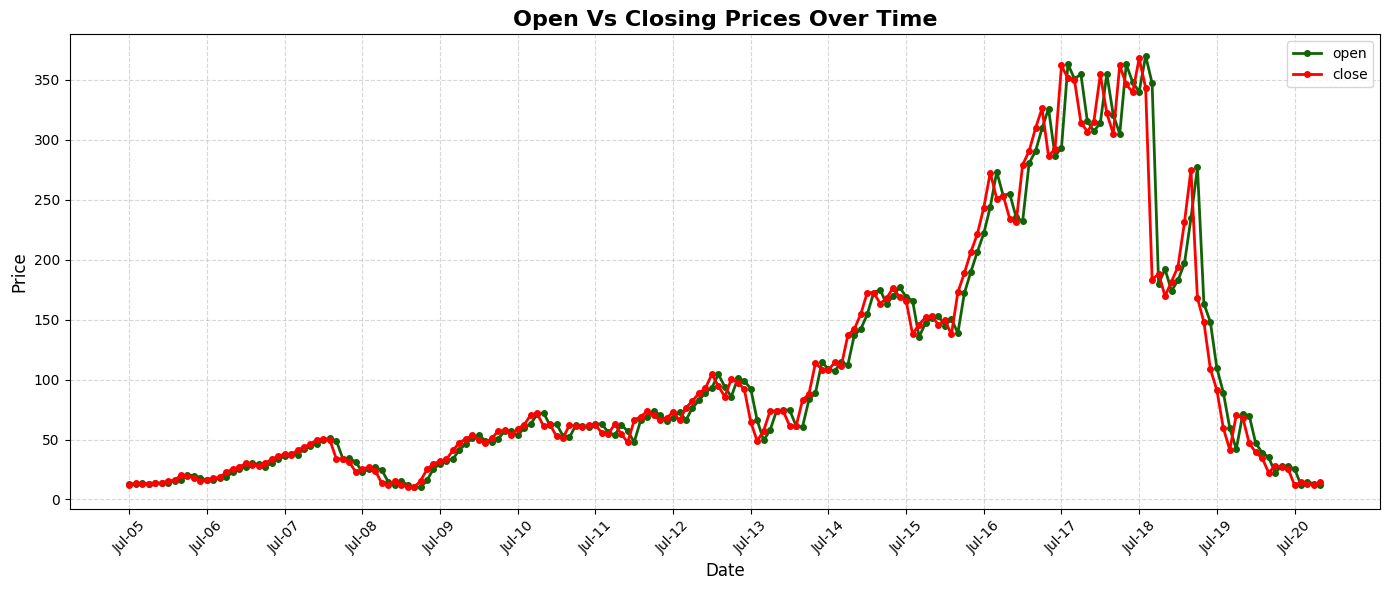

In [18]:
# Chart - 3 visualization code
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Open'], color='#136207', linewidth=2, marker='o', markersize=4,label="open")
plt.plot(df['Date'], df['Close'], color='red', linewidth=2, marker='o', markersize=4,label="close")

plt.title('Open Vs Closing Prices Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.xticks(df['Date'][::12], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used this line chart because it compares the opening price and closing price over time. This helps us understand whether the stock usually closes higher or lower than its opening price and shows the overall movement pattern of Yes Bank stock.

##### 2. What is/are the insight(s) found from the chart?

- The open price and the closing price are very close in the time between July 2005 and Jan 2008
- The open and close prices are moving very close to each other, which shows a strong relationship between both variables.
- From 2005 to 2017, both open and close prices show an overall upward trend.
- From 2016 to 2017 the closing price is higher than the opening price in maximum days 
- Around 2018, both prices reached very high levels.
- After 2018, both open and close prices declined sharply, showing a major fall in stock performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact because comparing open and close prices helps investors understand daily/monthly price behavior and market direction. If the closing price is often near or above the opening price, it can indicate positive market sentiment.

Yes, there is negative growth after 2018, where both open and close prices dropped sharply. This indicates high risk, weak investor confidence, and a negative impact on investment decisions.

#### Chart - 4

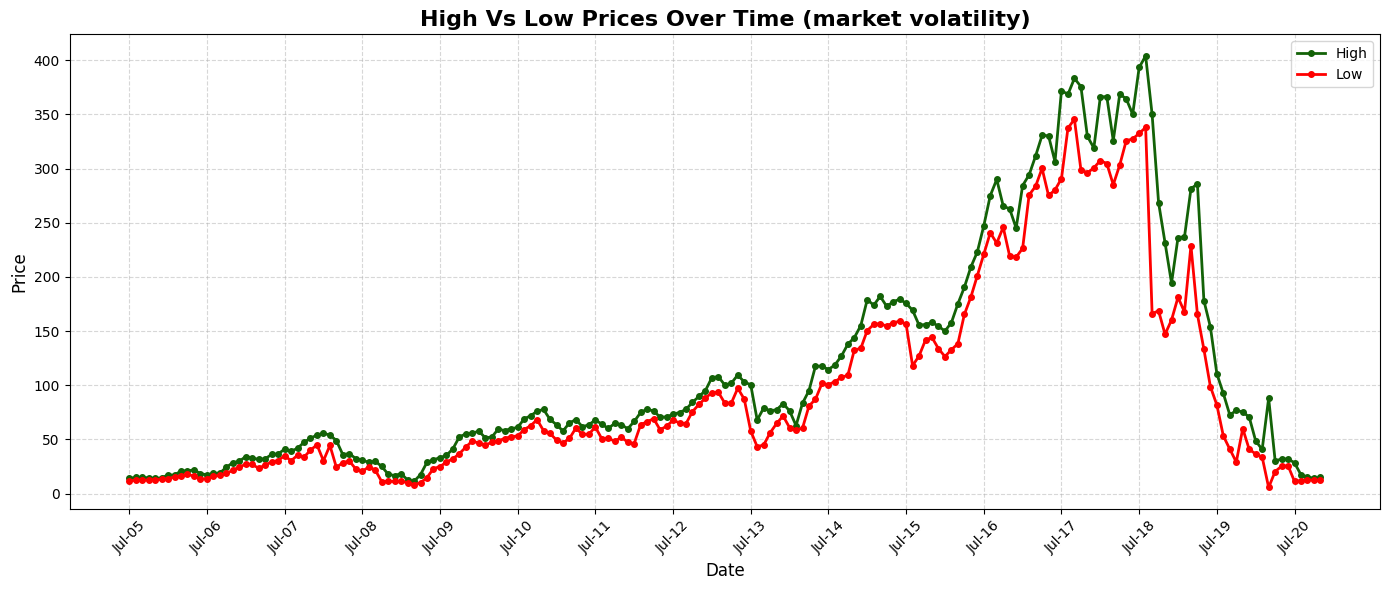

In [19]:
# Chart - 4 visualization code
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['High'], color='#136207', linewidth=2, marker='o', markersize=4,label="High")
plt.plot(df['Date'], df['Low'], color='red', linewidth=2, marker='o', markersize=4,label="Low")

plt.title('High Vs Low Prices Over Time (market volatility)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.xticks(df['Date'][::12], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This chart explains The market volatility , A higher difference between High and Low price indicates higher volatility. It means the stock price fluctuated strongly during that period, which increases risk for investors.

##### 2. What is/are the insight(s) found from the chart?

- From July 2005 to July 2010, the market was less volatile because the gap between High and Low prices was small.
- From 2014 to 2018, the gap between High and Low prices increased, showing higher volatility.
- Around 2018, the stock showed very high volatility, meaning the price fluctuated strongly during that period.
- After 2018, both High and Low prices declined sharply, showing negative stock performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact because volatility analysis helps investors understand the risk level of the stock. When the gap between High and Low prices is small, the stock is more stable. When the gap is large, the stock becomes riskier for investment.

Yes, there is negative growth after 2018 because both High and Low prices declined sharply. This indicates weak stock performance, high market risk, and possible loss of investor confidence.

#### Chart - 5

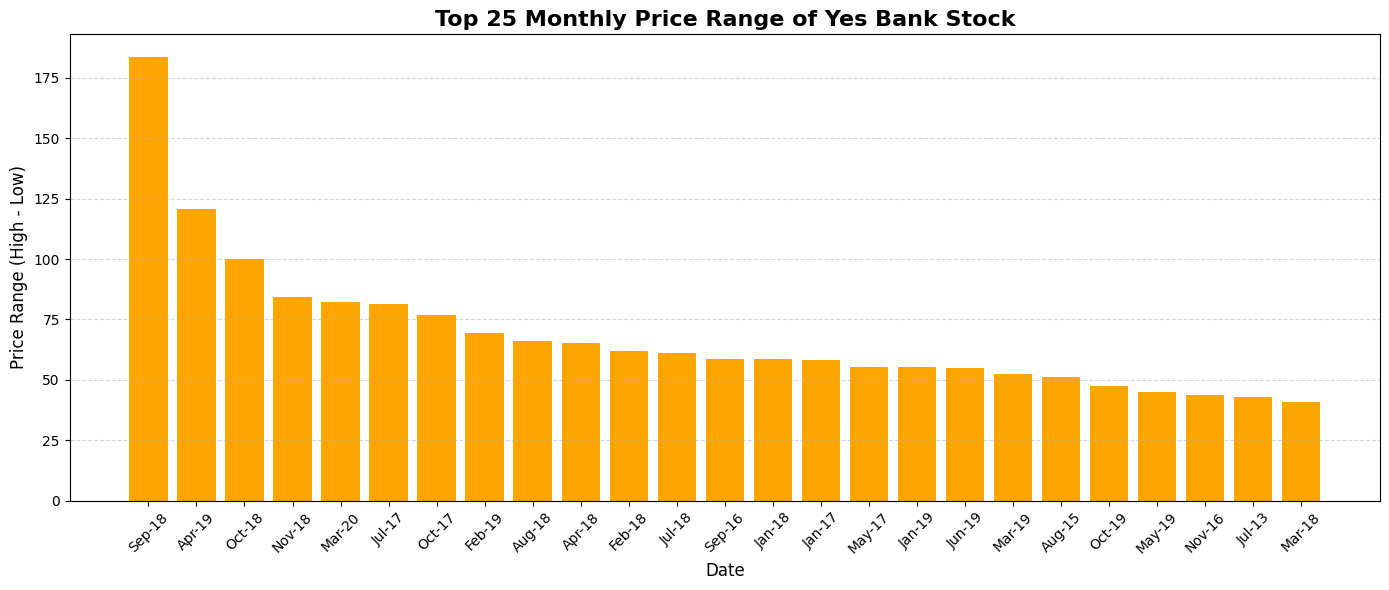

In [20]:
df_copy_1['Price_Range'] = df_copy_1['High'] - df_copy_1['Low']

top_25_PR = df_copy_1.sort_values(by='Price_Range', ascending=False).head(25)

plt.figure(figsize=(14,6))

plt.bar(top_25_PR['Date'], top_25_PR['Price_Range'], color='orange')

plt.title('Top 25 Monthly Price Range of Yes Bank Stock', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Range (High - Low)', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used this bar chart because it shows the monthly price range, calculated as High price minus Low price. This helps identify the months where Yes Bank stock had higher price fluctuation and higher volatility.

##### 2. What is/are the insight(s) found from the chart?

- The last 3 months of 2018 is very volatile and it contains maximum risk 
- A higher price range means the stock price moved a lot within that month, showing higher market risk.
- The highest bars represent the most volatile months for Yes Bank stock.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact because investors can identify risky months by looking at the price range. A smaller price range indicates more stability, while a larger price range shows higher volatility and risk.


#### Chart - 6

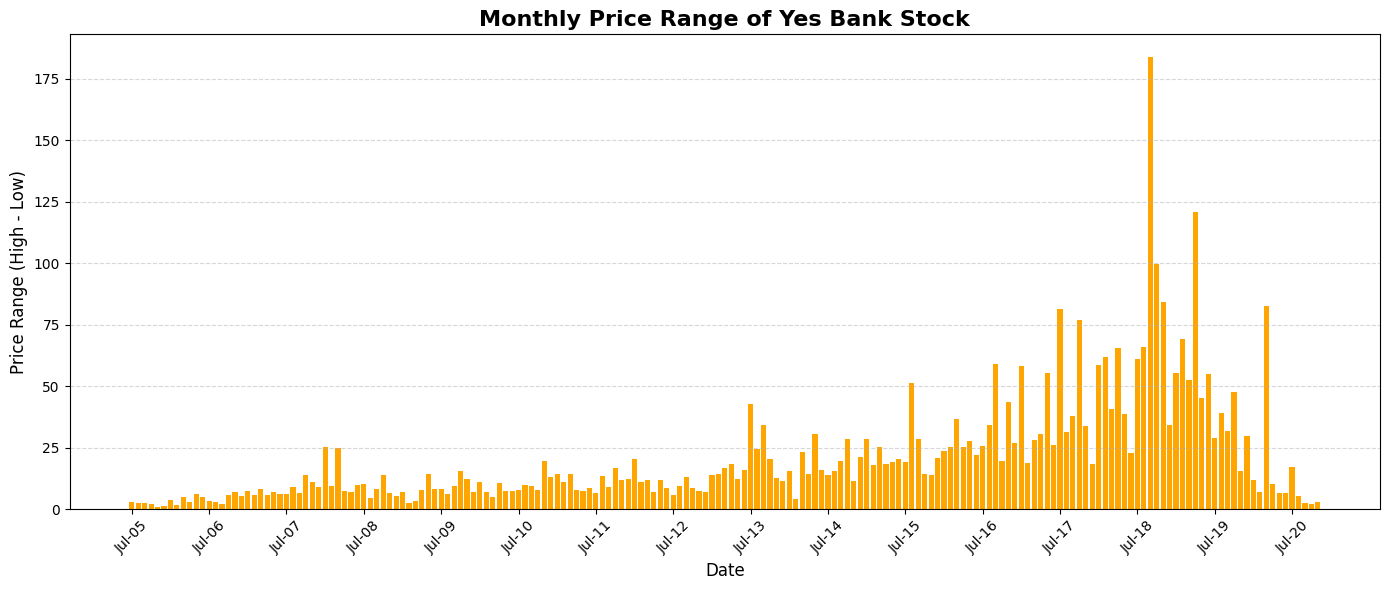

In [21]:
# Chart - 6 visualization code
plt.figure(figsize=(14,6))

plt.bar(df_copy_1['Date'], df_copy_1['Price_Range'], color='orange')

plt.title('Monthly Price Range of Yes Bank Stock', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Range (High - Low)', fontsize=12)

plt.xticks(df_copy_1['Date'][::12], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I perfomed this bar chart to watch the fluctuating price over the time 

##### 2. What is/are the insight(s) found from the chart?

- The time with the minimum risk is July 2005 to July 2012
- July 2013 to July 2016 , the risk is in medium level 
- the maximum fluctuation of the stock prices takes place in between July 2017 to July 2019

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact because the price range shows the volatility and risk level of Yes Bank stock over time. Investors can use this information to identify safer periods with low fluctuation and risky periods with high fluctuation.

Yes, there are negative insights. From July 2017 to July 2019, the stock showed maximum fluctuation, which indicates high volatility, higher investment risk, and unstable market behavior. This could negatively affect investor confidence and decision-making.

#### Chart - 7

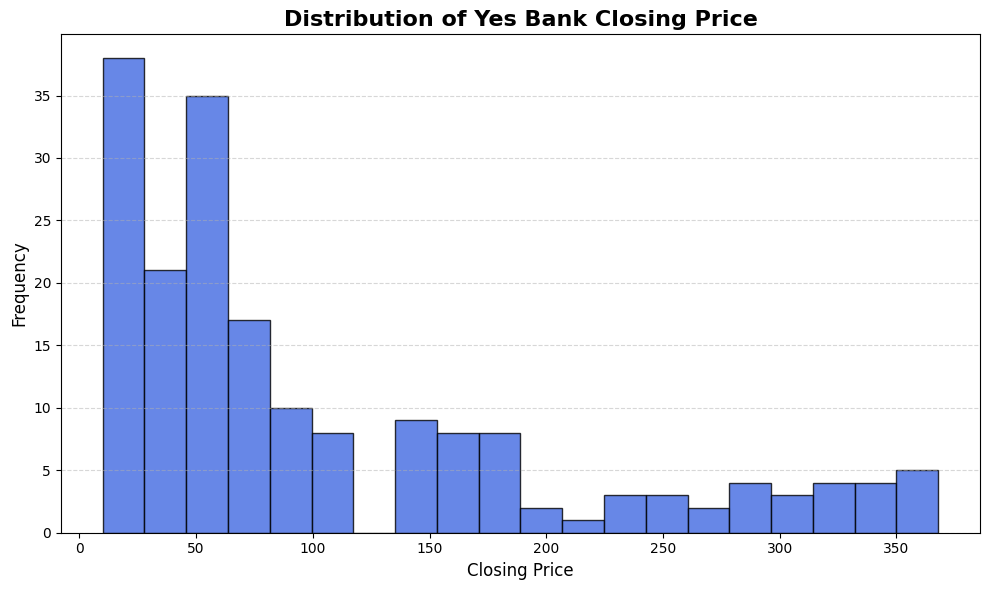

In [22]:
# Chart - 7 visualization code
plt.figure(figsize=(10,6))

plt.hist(df['Close'], bins=20, color='royalblue', edgecolor='black', alpha=0.8)

plt.title('Distribution of Yes Bank Closing Price', fontsize=16, fontweight='bold')
plt.xlabel('Closing Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

It allows us to quickly see the frequency of different price ranges, identify the most common price levels, and understand the overall shape and skewness of the stock price data.

##### 2. What is/are the insight(s) found from the chart?

- The most frequent closing prices occurred in the range of approximately ₹10 to ₹50, as shown by the tallest bars on the left.
-  High closing prices (above ₹200) were very infrequent

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The strong right-skew is an insight that points to negative growth. It signifies that periods of low valuation were far more common than periods of high valuation.

#### Chart - 8

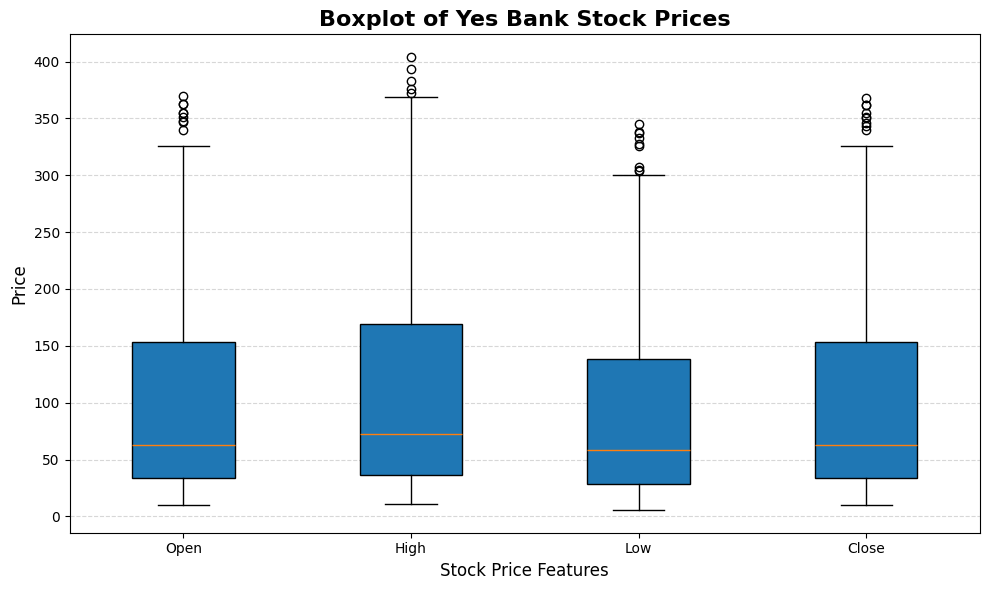

In [23]:
# Chart - 8 visualization code
plt.figure(figsize=(10,6))

plt.boxplot(
    [df['Open'], df['High'], df['Low'], df['Close']],
    tick_labels=['Open', 'High', 'Low', 'Close'],
    patch_artist=True
)

plt.title('Boxplot of Yes Bank Stock Prices', fontsize=16, fontweight='bold')
plt.xlabel('Stock Price Features', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a boxplot to easily compare how the 'Open', 'High', 'Low', and 'Close' prices are spread out. It helps to quickly see the typical price range, where most prices fall, and if there are any unusually high or low prices for each.

##### 2. What is/are the insight(s) found from the chart?

- All four prices (Open, High, Low, Close) generally follow a similar pattern and are often in the same range.
- There are many unusually high prices (outliers) for all price types, meaning the stock sometimes jumped very high.
- The prices are mostly lower, but occasionally reach very high values, showing a "right-skewed" pattern.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights are useful. Knowing the typical price ranges and when extreme prices happen helps investors understand the stock's risk and potential.

#### Chart - 9

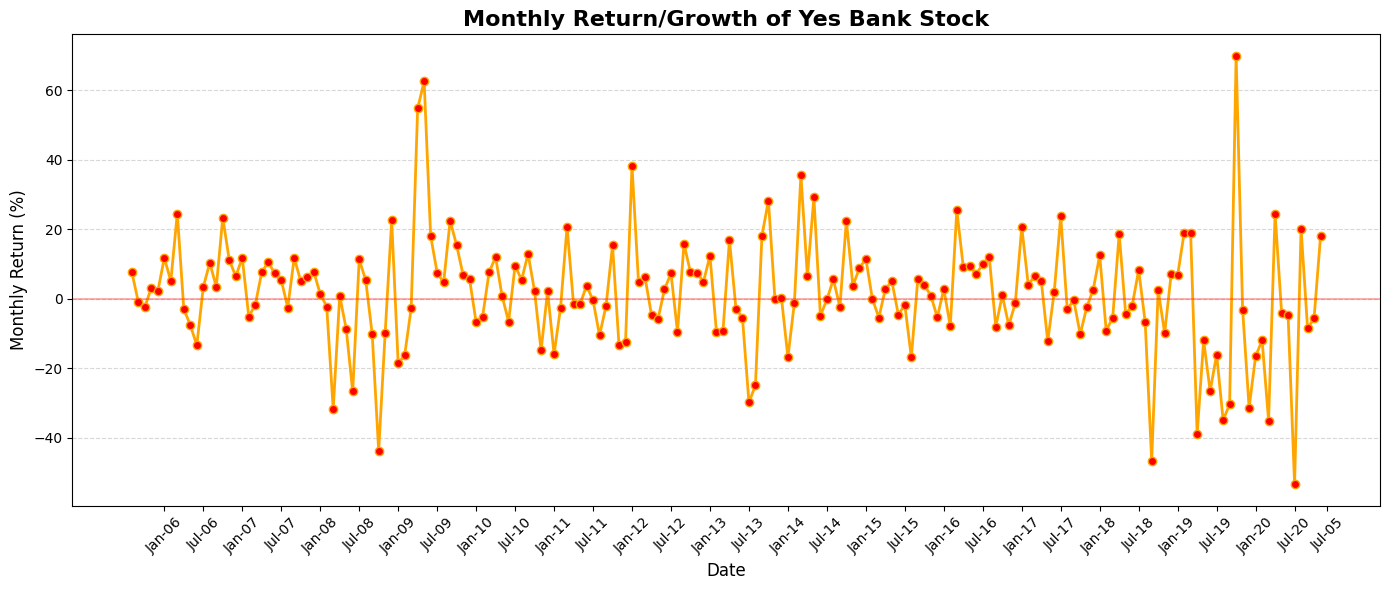

In [24]:
plt.figure(figsize=(14,6))

plt.plot(df_copy_1['Date'].iloc[1:], df_copy_1['Return'].iloc[1:], 
        color='orange', linewidth=2,marker='o',markerfacecolor='red')

plt.title('Monthly Return/Growth of Yes Bank Stock', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Monthly Return (%)', fontsize=12)

plt.xticks(df_copy_1['Date'].iloc[::6], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.axhline(y=0, color='red', alpha=0.3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used this line chart because it shows the monthly return or growth percentage of Yes Bank stock based on the closing price. This helps us understand whether the stock gained or lost value compared to the previous month.

##### 2. What is/are the insight(s) found from the chart?

- The returns fluctuate above and below zero, which shows that the stock had both profit and loss periods.
- Positive return values indicate months where the closing price increased compared to the previous month.
- Negative return values indicate months where the closing price decreased compared to the previous month.
- Some months show sharp positive or negative returns, which indicates high volatility in Yes Bank stock.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, there are negative growth periods because the chart has return values below zero. These negative returns indicate months where the stock price fell compared to the previous month, which can reduce investor confidence and increase investment risk

#### Chart - 10 - Correlation Heatmap

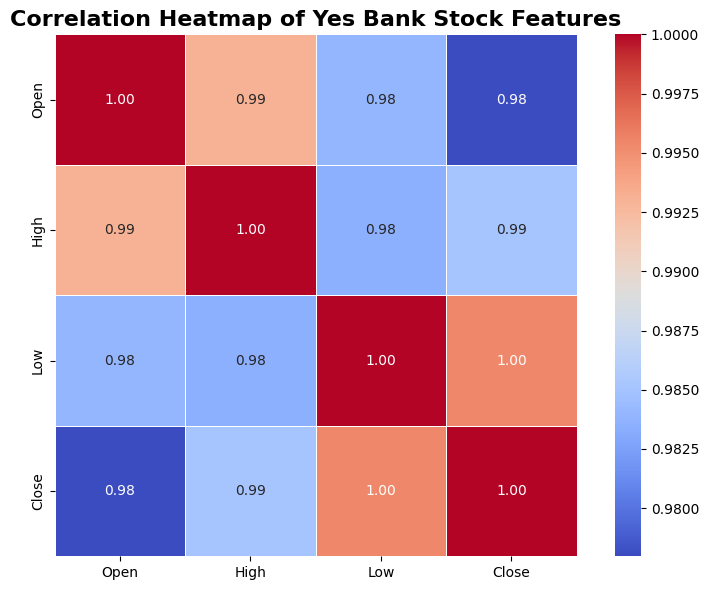

In [29]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f',
    square=True
)

plt.title('Correlation Heatmap of Yes Bank Stock Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I used the correlation heatmap because it shows the strength of relationship between numerical variables like Open, High, Low, and Close. This helps identify which features are strongly related to the target variable Close.

##### 2. What is/are the insight(s) found from the chart?

- Open, High, Low, and Close are highly positively correlated with each other.
- Close price has a very strong relationship with Open, High, and Low prices.
- This means Open, High, and Low can be useful input features for predicting the Close price.
- There is no weak relationship among the stock price features, which shows that all price columns move in a similar direction.

#### Chart - 11 - Pair Plot

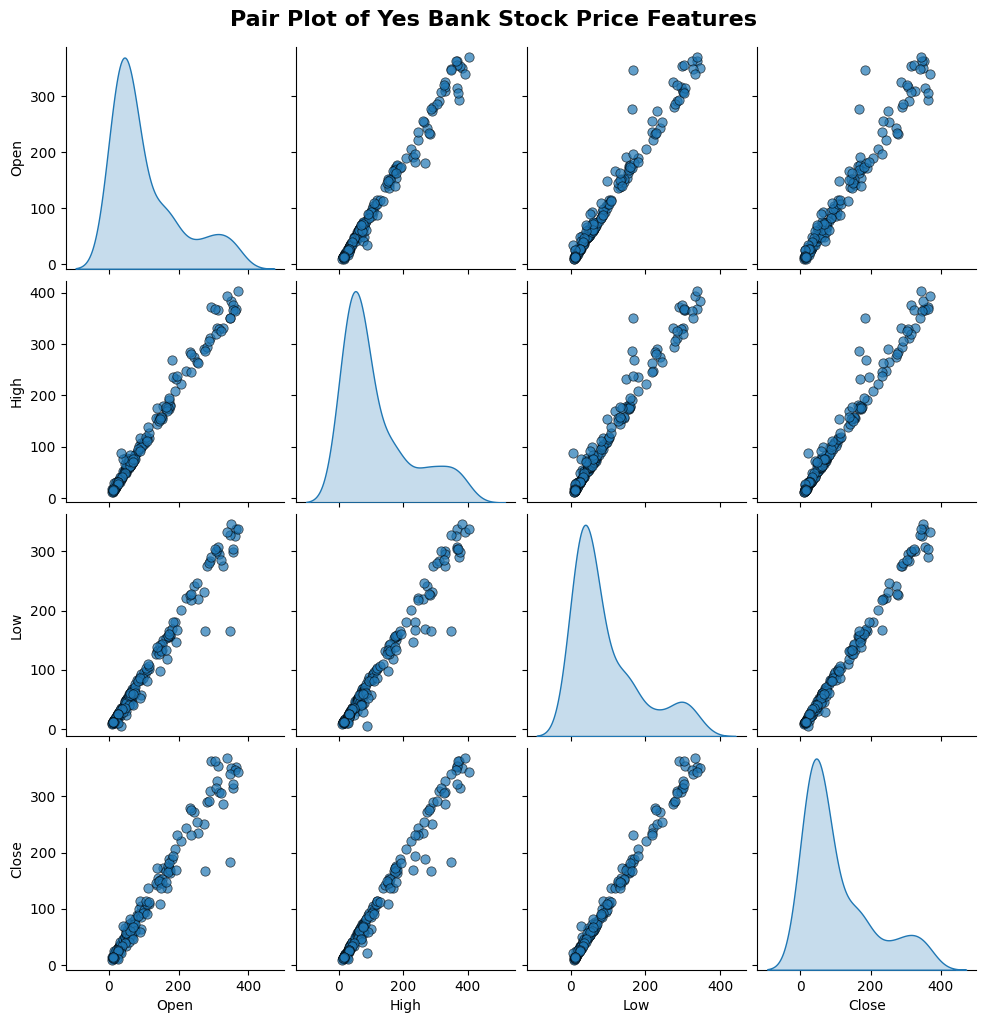

In [30]:
# Pair plot visualization code
sns.pairplot(
    df[['Open', 'High', 'Low', 'Close']],
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 45, 'edgecolor': 'black'},
    diag_kws={'fill': True}
)

plt.suptitle('Pair Plot of Yes Bank Stock Price Features', fontsize=16, fontweight='bold', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

I used the pair plot because it shows the relationship between all stock price features in one visual. It helps us understand how Open, High, Low, and Close move with each other and whether they have a linear relationship.

##### 2. What is/are the insight(s) found from the chart?

- Open, High, Low, and Close show strong positive relationships with each other.
- The scatter plots show an almost linear pattern, meaning when one price feature increases, the others also increase.
- Close price is strongly related to Open, High, and Low, so these variables can be useful for prediction.
- The diagonal plots show the distribution of each price feature, helping us understand the spread of values.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- H0: There is no significant difference between Open price and Close price.
- H1: There is a significant difference between Open price and Close price.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

open_mean = df['Open'].mean()
close_mean = df['Close'].mean()

difference = df['Close'] - df['Open']
difference_mean = difference.mean()
difference_std = difference.std()

t_stat, p_value = stats.ttest_rel(df['Close'], df['Open'])

print("Open Mean:", open_mean)
print("Close Mean:", close_mean)
print("Mean Difference:", difference_mean)
print("Standard Deviation of Difference:", difference_std)
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: There is a significant difference between Open and Close price.")
else:
    print("Fail to Reject H0: There is no significant difference between Open and Close price.")

Open Mean: 105.5414054054054
Close Mean: 105.2047027027027
Mean Difference: -0.3367027027027039
Standard Deviation of Difference: 20.72583717413467
T-statistic: -0.220963420803944
P-value: 0.825365920365391
Fail to Reject H0: There is no significant difference between Open and Close price.


##### Which statistical test have you done to obtain P-Value?

Related T test here 

##### Why did you choose the specific statistical test?

As both features are from the same sample so i use related T test here 

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- H0: There is no significant difference between High price and Low price.
- H1: There is a significant difference between High price and Low price.

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value

high_mean = df['High'].mean()
low_mean = df['Low'].mean()

HL_difference = df['High'] - df['Low']
difference_mean = HL_difference.mean()
difference_std = HL_difference.std()

t_stat, p_value = stats.ttest_rel(df['High'], df['Low'])

print("High Mean:", high_mean)
print("Low Mean:", low_mean)
print("Mean Difference:", difference_mean)
print("Standard Deviation of Difference:", difference_std)
print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: There is a significant difference between High and Low price.")
else:
    print("Fail to Reject H0: There is no significant difference between High and Low price.")

High Mean: 116.10432432432432
Low Mean: 94.94783783783782
Mean Difference: 21.156486486486486
Standard Deviation of Difference: 23.45287073559025
T-statistic: 12.26968460529332
P-value: 1.1296104911289583e-25
Reject H0: There is a significant difference between High and Low price.


##### Which statistical test have you done to obtain P-Value?

Related T test

##### Why did you choose the specific statistical test?

As both features are from the same sample so i use related T test here 

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

- H0: There is no significant correlation between Open price and Close price.
- H1: There is a significant correlation between Open price and Close price.

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value

corr_coeff, p_value = stats.pearsonr(df['Open'], df['Close'])

print("Correlation Coefficient:", corr_coeff)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject H0: There is a significant correlation between Open price and Close price.")
else:
    print("Fail to Reject H0: There is no significant correlation between Open price and Close price.")

Correlation Coefficient: 0.9779710062230934
P-value: 1.852774505867184e-126
Reject H0: There is a significant correlation between Open price and Close price.


##### Which statistical test have you done to obtain P-Value?

Pearson correlation test

##### Why did you choose the specific statistical test?

Open and Close are continuous numerical columns.
We want to test whether they move together.
So Pearson correlation is suitable.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [34]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

#### What all missing value imputation techniques have you used and why did you use those techniques?

- There is no missing value in any column in the dataset , so no need of imputation techniques

### 2. Handling Outliers

In [35]:
# Handling Outliers & Outlier treatments

price_cols = ['Open', 'High', 'Low', 'Close']

for col in price_cols:
    df_model[col] = np.log1p(df_model[col])

##### What all outlier treatment techniques have you used and why did you use those techniques?

I handled outliers using log transformation instead of removing them because stock price outliers represent real market behavior. Log transformation reduces the effect of extreme values while preserving important information.

### 3. Categorical Encoding

In [36]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Categorical encoding is not required because the dataset does not contain categorical variables. The Date column was converted into numerical Year and Month features for model building.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [48]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [49]:
# Select your features wisely to avoid overfitting

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

### 8. Data Splitting

In [52]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X = df_model[['Open', 'High', 'Low', 'Year', 'Month']]
y = df_model['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##### What data splitting ratio have you used and why?

I used ideal ratio of 80:20 , 20% data should be reserved as the Testing dataset 

### 6. Data Scaling

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Which method have you used to scale you data and why?

I use StandardScaler here , specially for the 'year' column as it's value is much higher than other columns so it might get extra weightage 

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, the dataset is not considered imbalanced because this is a regression problem, not a classification problem. The target variable Close is continuous, so class imbalance does not apply here.

In [54]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

## Helper Function to evaluate Model

In [55]:
model_results = {}

def evaluate_model(model_name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    model_results[model_name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

    print(model_name)
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

### ML Model - 1 : LinearRegression Model

In [56]:
# ML Model - 1 Implementation

# Fit the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on model
y_pred_lr = lr_model.predict(X_test_scaled)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [57]:
# Visualizing evaluation Metric Score chart
# Evaluation
evaluate_model("Linear Regression", y_test, y_pred_lr)

Linear Regression
MAE: 0.06251077447309883
MSE: 0.007768060653429587
RMSE: 0.08813660223442692
R2 Score: 0.9902021152565701


#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='r2')

print("Linear Regression CV Scores:", lr_cv_scores)
print("Mean CV Score:", lr_cv_scores.mean())

Linear Regression CV Scores: [0.99476769 0.99645867 0.99820413 0.9900845  0.99696632]
Mean CV Score: 0.9952962640030047


##### Which hyperparameter optimization technique have you used and why?

Linear Regression does not have important hyperparameters for tuning, so only cross-validation was performed to check model stability.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2 : Ridge Regression Model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [59]:
# Visualizing evaluation Metric Score chart
# Fit the model
ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)

# Predict on model
y_pred_ridge = ridge_model.predict(X_test_scaled)
# Evaluation
evaluate_model("Ridge Regression", y_test, y_pred_ridge)

Ridge Regression
MAE: 0.06918942851144681
MSE: 0.008727358242423251
RMSE: 0.09342033099076053
R2 Score: 0.9889921495223992


#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

ridge_cv_scores = cross_val_score(ridge_model, X_train_scaled, y_train, cv=5, scoring='r2')

print("Linear Regression CV Scores:", ridge_cv_scores)
print("Mean CV Score:", ridge_cv_scores.mean())
print()

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", ridge_grid.best_params_)
print("Best CV Score:", ridge_grid.best_score_)

best_ridge = ridge_grid.best_estimator_

y_pred_best_ridge = best_ridge.predict(X_test_scaled)

evaluate_model("Tuned Ridge Regression", y_test, y_pred_best_ridge)

Linear Regression CV Scores: [0.98902437 0.99476128 0.99629439 0.98405184 0.99528931]
Mean CV Score: 0.9918842369278732

Best Parameters: {'alpha': 0.01}
Best CV Score: 0.9952893841403181
Tuned Ridge Regression
MAE: 0.062366075572036044
MSE: 0.007728739285492768
RMSE: 0.08791324863462144
R2 Score: 0.990251711449003


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter optimization. GridSearchCV tries different combinations of hyperparameters and selects the best combination based on cross-validation score. I used it because the dataset is small, so testing multiple parameter combinations is manageable and helps improve model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

- R2 score improves 0.13 from 98.89 to 99.02 
- cv score is also improved 

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3 : Random Forest Regressor 

In [61]:
# ML Model - 3 Implementation

# Fit the model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on model
y_pred_rf = rf_model.predict(X_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [62]:
# Visualizing evaluation Metric Score chart

# Evaluation
evaluate_model("Random Forest Regressor", y_test, y_pred_rf)

Random Forest Regressor
MAE: 0.10966218090656497
MSE: 0.032910345586679914
RMSE: 0.18141208776341206
R2 Score: 0.958490054685351


#### 2. Cross- Validation & Hyperparameter Tuning

In [63]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

rf_cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='r2')

print("Linear Regression CV Scores:", rf_cv_scores)
print("Mean CV Score:", rf_cv_scores.mean())
print()
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

evaluate_model("Tuned Random Forest Regressor", y_test, y_pred_best_rf)

Linear Regression CV Scores: [0.98606047 0.98667736 0.99520303 0.98380181 0.99422508]
Mean CV Score: 0.98919355252471

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.989841903407403
Tuned Random Forest Regressor
MAE: 0.10666186664118821
MSE: 0.030051279019116948
RMSE: 0.17335304733149903
R2 Score: 0.962096206330216


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter optimization. GridSearchCV tries different combinations of hyperparameters and selects the best combination based on cross-validation score. I used it because the dataset is small, so testing multiple parameter combinations is manageable and helps improve model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

## **Evaluation Metric Score Chart Visualization for All Models**

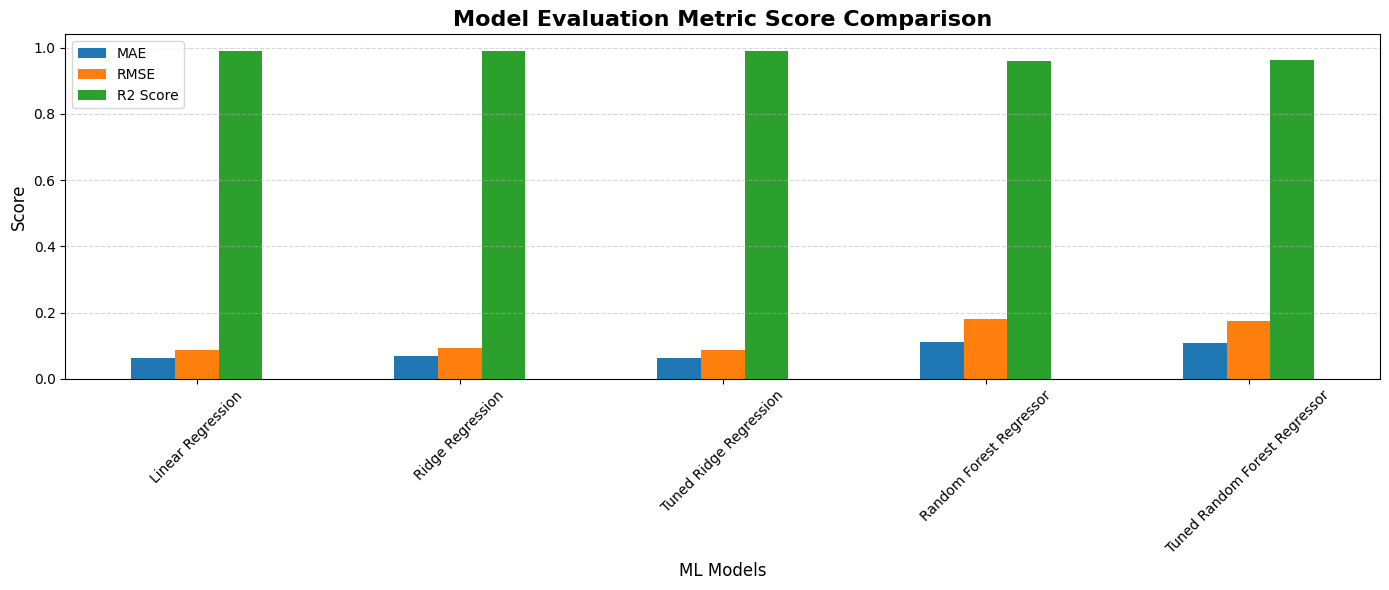

,MAE,MSE,RMSE,R2 Score
Linear Regression,0.062511,0.007768,0.088137,0.990202
Ridge Regression,0.069189,0.008727,0.093420,0.988992
Tuned Ridge Regression,0.062366,0.007729,0.087913,0.990252
Random Forest Regressor,0.109662,0.032910,0.181412,0.958490
Tuned Random Forest Regressor,0.106662,0.030051,0.173353,0.962096


In [64]:
results_df = pd.DataFrame(model_results).T

results_df[['MAE', 'RMSE', 'R2 Score']].plot(kind='bar', figsize=(14,6))

plt.title('Model Evaluation Metric Score Comparison', fontsize=16, fontweight='bold')
plt.xlabel('ML Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

results_df

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered R2 Score as the main evaluation metric for positive business impact because it shows how well the model explains the variation in the Close price. A higher R2 Score means the model is able to predict the closing price more accurately using the given input features.

For this business problem, a good R2 Score is important because accurate stock closing price prediction can help investors and analysts make better buy, sell, or hold decisions.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected Linear Regression as the final prediction model because it gives a very high R2 Score of 0.9902, which means the model explains around 99% of the variation in the Close price. It also has low error values with MAE of 0.0625 and RMSE of 0.0881.

Although Tuned Ridge Regression gives a slightly higher R2 Score, the improvement is very small. Therefore, Linear Regression is preferred because it is simple, interpretable, and performs almost equally well.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [65]:
# Save the File

# Save final Linear Regression model and scaler
joblib.dump(lr_model, 'linear_regression_model.pkl')
joblib.dump(scaler, 'standard_scaler.pkl')

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [66]:
# Load the File and predict unseen data.

loaded_model = joblib.load('linear_regression_model.pkl')
loaded_scaler = joblib.load('standard_scaler.pkl')

# Take one unseen/test row for sanity check
unseen_data = X_test.iloc[[10]]

# Scale unseen data
unseen_data_scaled = loaded_scaler.transform(unseen_data)

# Predict
prediction = loaded_model.predict(unseen_data_scaled)

print("Unseen Data:")
print(unseen_data)
print()

print("Predicted Close Price Original Scale:", np.expm1(prediction[0]))
print("Actual Close Price Original Scale:", np.expm1(y_test.iloc[10]))

Unseen Data:
        Open      High       Low  Year  Month
97  4.204693  4.231349  3.789177  2013      8

Predicted Close Price Original Scale: 48.91465050265767
Actual Close Price Original Scale: 48.65


# **Conclusion**

The project successfully analyzed Yes Bank OHLC stock data and built a regression model to predict the closing price. The analysis showed strong relationships between Open, High, Low, and Close prices, with high volatility after 2018. Linear Regression was selected as the final model because it gave a high R2 Score and low error values.